In [ ]:
# UW x Duke collaboration
# 
# By Ian Wildemann
# Duke University
# Green System
# Professor Crystal Noel
#
# Axial mode calculation
# 
# Description:
# Effect of an optical tweezer on the axial mode structure of a trapped ion chain
# The ion we are using is Barium 137+ and this is the effect of a 1 um beam at 532 nm tweezer wavelength.
# This code plots the frequency shift of the normal modes of a trapped ion chain as a function of optical tweezer power.
#   At each power the optical tweezer trap frequency is recalculated, the new ion equlibrium positions are found, the Hessian
#   is recalculated. The eigenvectors of this Hessian are the normal modes vectors and the eigenvalues give the mode frequencies.
# This code also calculates the participation of each ion in each axial mode as a function of optical tweezer power,
#   This allows us to see how the optical tweezer localizes motion of the tweezed ion in the normal modes of the chain.
#   Participation is plotted at a higher power to better see the effects of the tweezer on the chain.




import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker

#Constants in SI units
eps0 = constants.epsilon_0 
mBa137 = 136.9058 * constants.atomic_mass
mBa138 = 137.905232 * constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
h = constants.h 
pi = np.pi

# setting up parameters that we're not changing
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
linewidths = np.array([2*pi*20.5e6,2*pi*25.2e6])
lifetimes = linewidths
branching_ratios = np.array([0.732,0.702])
#branching_ratios = np.array([1,1])
linewidths = linewidths * branching_ratios
lambda_res = np.array([493.545e-9,455.531e-9])
omega_res = 2*pi*c/lambda_res

# Radial and axial frequencies for the trap with no tweezers
w_rf_r = 2*pi*3e6
w_rf_a = 2*pi*400e3
# Radial and axial frequencies that the tweezers add at 96 mW - this should be updated per power in a power sweep
w_tw_r = 2*pi*210e3
w_tw_a = 2*pi*25e3
NA = 0.1
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")



# User settings - change these depending on what you want to simulate
N = 3
tweezed_ion = 0
tweezed_ions = [tweezed_ion]
beam_waist = 1e-6
power = 3000e-3
intensity = 2*power/(pi*beam_waist**2)






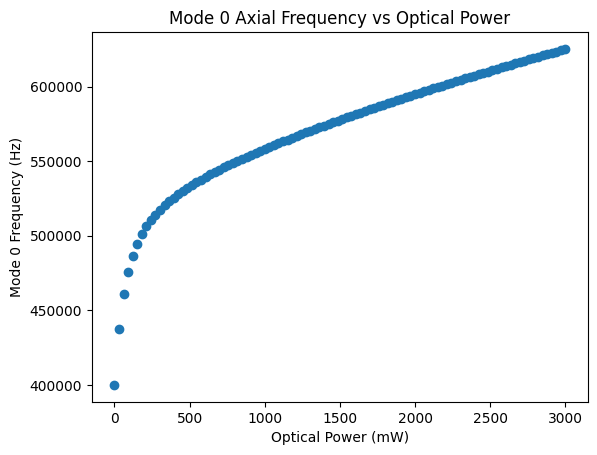

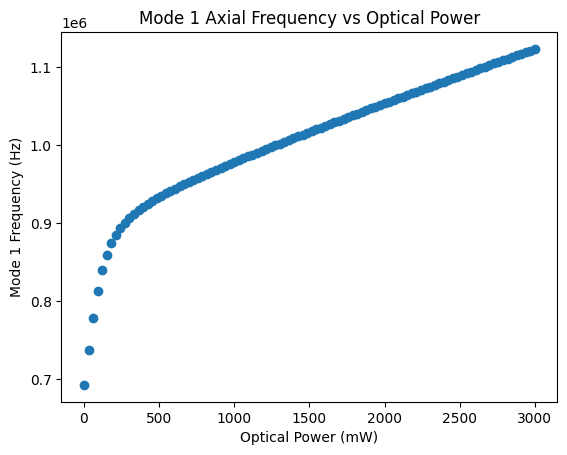

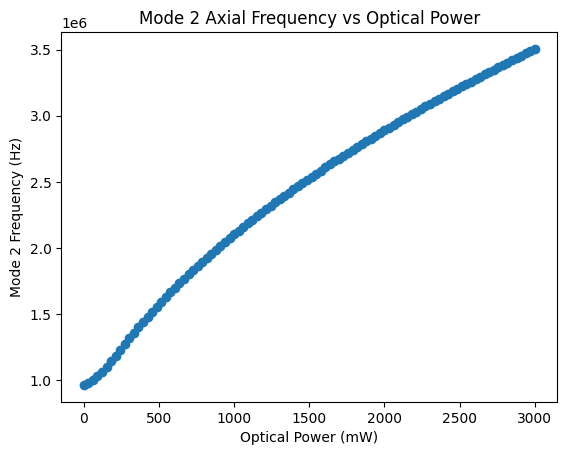

In [ ]:
P_opt = np.linspace(0,power,100) #going from 0 to 1 W 


Modes = []
participations_axial_by_mode = []

# Iterate over optical powers
for j in range(len(P_opt)):
    # Calculate new ion equilibrium positions
    U_new = potential(omega_tweezer,linewidths,omega_res,P_opt[j],beam_waist)

    # Get new radial trap frequency from the optical potential
    omega_tw_radial_new = tweezer_optical_potential_to_trap_frequency(
       tweezer_wavelength,linewidths,omega_res,P_opt[j],beam_waist,m,U_new)[0] / (2*pi)

    # Get new ion equilibrium position
    ueq_tw_axial_new = ion_spacing_tweezers(pot_derivative_with_tweeze, ion_spacing(N, w_rf_a), omega_rf_axial=w_rf_a, omega_tw_radial=omega_tw_radial_new, tweezed_ion=tweezed_ion, displacement=0)[0]

    # Get modes for the tweezed system 
    mode_data = physical_params_to_axial_mode_vectors(N,ueq_tw_axial_new,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt[j],beam_waist,m,U_new)

    # Save both frequencies and mode vectors
    Modes.append({
        "frequencies": [rm[0] for rm in mode_data],  # Extract frequencies
        "vectors": [rm[1] for rm in mode_data]       # Extract mode vectors
    })

    # Each row = one mode, each column = ion contribution
    # shape: (num_modes, num_ions)
    p_modes = np.array([np.abs(vec)**2 for _, vec in mode_data])

    participations_axial_by_mode.append(p_modes)

# Final array shape: (num_powers, num_modes, num_ions)
participations_axial_by_mode = np.array(participations_axial_by_mode)


# print mode 0 frequencies by optical power
mode_0_frequencies = [Modes[j]["frequencies"][0] for j in range(len(P_opt))]
I_opt = 2 * P_opt / (np.pi * beam_waist**2)
plt.scatter(P_opt*1e3,mode_0_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode 0 Frequency (Hz)")
plt.title("Mode 0 Axial Frequency vs Optical Power")
plt.show()





'''
mode_index = 0
for mode_index in range(N):
    plt.plot(P_opt*1e3, participations_axial_by_mode[:, mode_index, 0], 'o-', label=f"Ion 0")
    plt.plot(P_opt*1e3, participations_axial_by_mode[:, mode_index, 1], 'o-', label=f"Ion 1")
    plt.plot(P_opt*1e3, participations_axial_by_mode[:, mode_index, 2], 'o-', label=f"Ion 2")
    plt.xlabel("Power (mW)")
    plt.ylabel("Participation")
    plt.ylim(0, 1)
    plt.title(f"Ion contributions to Axial mode {mode_index} when tweezing ion {tweezed_ion+1} with {N} ions in a chain")
    # make the legend say one ion greater than the ion number since we're 0 indexed but the plot should be 1 indexed
    mode_labels = ["Ion 1", "Ion 2", "Ion 3", "Ion 4", "Ion 5"]
    plt.legend([mode_labels[i] for i in range(N)])
    plt.grid()
    plt.show()

'''    


# print mode 0 frequencies by optical power
mode_0_frequencies = [Modes[j]["frequencies"][1] for j in range(len(P_opt))]
plt.scatter(P_opt*1e3,mode_0_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode 1 Frequency (Hz)")
plt.title("Mode 1 Axial Frequency vs Optical Power")
plt.show()

# print mode 0 frequencies by optical power
mode_0_frequencies = [Modes[j]["frequencies"][2] for j in range(len(P_opt))]
plt.scatter(P_opt*1e3,mode_0_frequencies)
plt.xlabel("Optical Power (mW)")
plt.ylabel("Mode 2 Frequency (Hz)")
plt.title("Mode 2 Axial Frequency vs Optical Power")
plt.show()


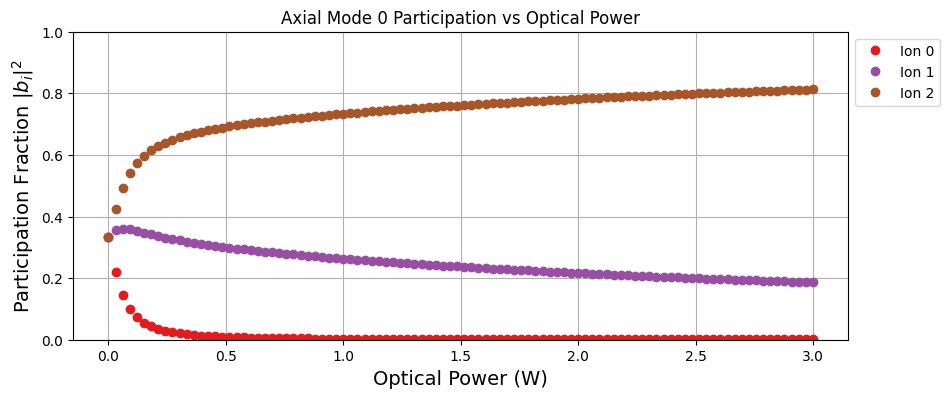

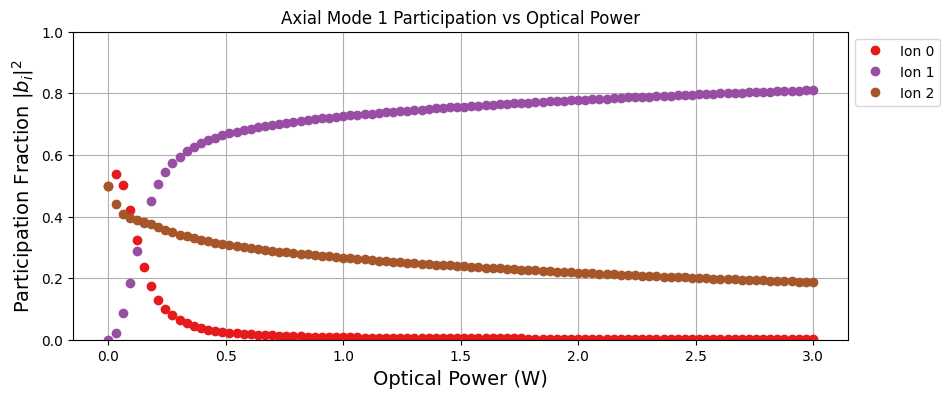

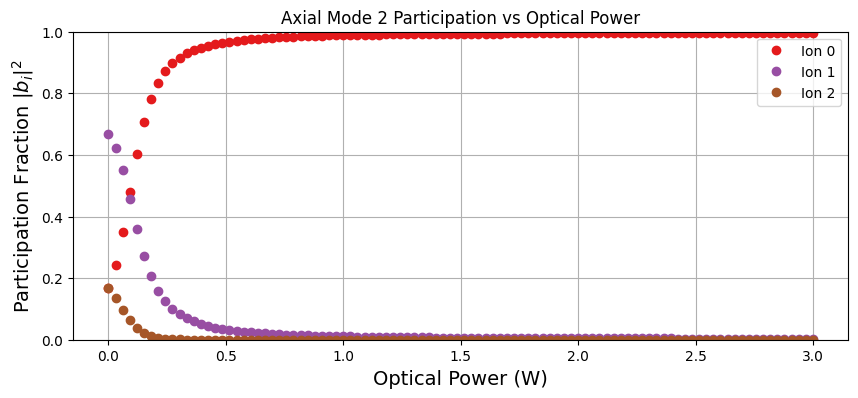

In [34]:
import matplotlib.pyplot as plt

set2_colors = plt.get_cmap('Set1').colors  # Tuple of 8 Set2 colors


custom_colors = [set2_colors[0], set2_colors[3], set2_colors[6]]
import matplotlib.pyplot as plt

set2_colors = plt.get_cmap('Set1').colors  # Tuple of 8 Set2 colors


custom_colors = [set2_colors[0], set2_colors[3], set2_colors[6]]

participation = {}

for mode_index in range(N):

    # Extract eigenvectors only (NO scaling)
    vectors = [mode_entry['vectors'][mode_index] for mode_entry in Modes]

    participation[mode_index] = {}

    plt.figure(figsize=(10, 4))

    for ion_index in range(len(vectors[0])):

        # Compute |b_i|^2 for each power point
        component_values = [np.abs(vec[ion_index])**2 for vec in vectors]

        # Optional: normalize (good practice)
        norm_values = [
            val / np.sum(np.abs(vec)**2)
            for val, vec in zip(component_values, vectors)
        ]

        participation[mode_index][ion_index] = norm_values

        color = custom_colors[ion_index % len(custom_colors)]
        plt.plot(P_opt, norm_values, 'o',
                 label=f'Ion {ion_index}',
                 linewidth=2, color=color)

    plt.title(f"Axial Mode {mode_index} Participation vs Optical Power")
    plt.xlabel('Optical Power (W)', fontsize=14)
    plt.ylabel('Participation Fraction $|b_i|^2$', fontsize=14)
    plt.ylim(0, 1)
    plt.legend(bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()

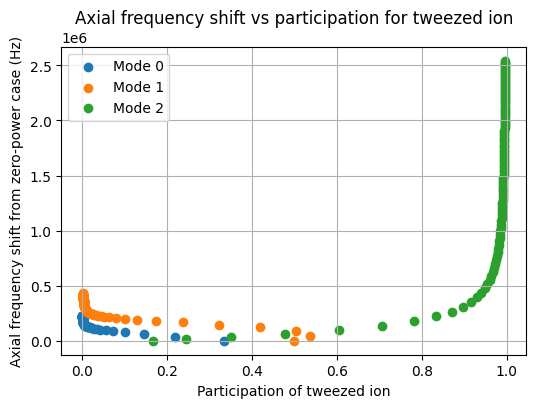

In [35]:
plt.figure(figsize=(6,4))

mode_labels = ["Mode 0", "Mode 1", "Mode 2"]

for mode_idx in range(N):
    # participation of the tweezed ion for this mode over all optical powers
    x = np.abs(participation[mode_idx][tweezed_ion])

    # frequency shift of this mode relative to the zero-power case
    y = np.array([
        Modes[i]["frequencies"][mode_idx] - Modes[0]["frequencies"][mode_idx]
        
        for i in range(len(P_opt))
    ])

    plt.scatter(x, y, label=mode_labels[mode_idx])

plt.xlabel(f"Participation of tweezed ion")
plt.ylabel("Axial frequency shift from zero-power case (Hz)")
plt.title(f"Axial frequency shift vs participation for tweezed ion")
plt.legend()
plt.grid(True)
plt.show()